In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import SGD

import numpy as np

In [2]:
# import numpy as np

# class Bias:
#     def __init__(self, h_size: int) -> None:
#         self._h_size = h_size
#         self._value = None

#     @property
#     def value(self):
#         if self._value is None:
#             self._value = self._generate_value()
#         return self._value

#     def _generate_value(self):
#         return np.random.uniform(-0.5, 0.5, size=(1, self._h_size))

#     def __call__(self):
#         return self.value

# class Weight:
#     def __init__(self, v_size: int, h_size: int):
#         self._v_size = v_size
#         self._h_size = h_size
#         self._value = None

#     @property
#     def value(self):
#         if self._value is None:
#             self._value = self._generate_value()
#         return self._value

#     def _generate_value(self):
#         return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

#     def __call__(self):
#         return self.value

# class LinearLayer:
#     def __init__(self, _input: int, _output: int):
#         self._input = _input
#         self._output = _output
#         self._bias = Bias(_output)()
#         self._weights = Weight(_input, _output)()
#         self._last_input = None  # Store input for backprop
#         self._last_output = None  # Store output before activation

#     def forward(self, x):
#         self._last_input = x  # Store input for backprop
#         self._last_output = np.dot(x, self._weights) + self._bias  # Linear transformation
#         return self._last_output

#     def backward(self, dL_dZ, learning_rate):
#         """ Backpropagate gradients and update weights """
#         dL_dW = np.dot(self._last_input.T, dL_dZ)  # Compute weight gradients
#         dL_db = np.sum(dL_dZ, axis=0, keepdims=True)  # Compute bias gradients

#         # Gradient Descent update
#         self._weights -= learning_rate * dL_dW
#         self._bias -= learning_rate * dL_db

#         # Compute gradient for previous layer
#         dL_dX = np.dot(dL_dZ, self._weights.T)
#         return dL_dX

# def relu_activation(layer):
#     """ Applies ReLU activation function """
#     return np.maximum(0, layer)

# def relu_derivative(layer):
#     """ Computes derivative of ReLU """
#     return (layer > 0).astype(float)

# class CustomNeuralNetwork:
#     def __init__(self, learning_rate=0.01):
#         self.input_layer = LinearLayer(2, 4)
#         self.hidden_layer = LinearLayer(4, 4)
#         self.output_layer = LinearLayer(4, 2)
#         self.learning_rate = learning_rate

#     def forward(self, x):
#         """ Forward pass through the network """
#         self.z1 = self.input_layer.forward(x)
#         self.a1 = relu_activation(self.z1)

#         self.z2 = self.hidden_layer.forward(self.a1)
#         self.a2 = relu_activation(self.z2)

#         self.z3 = self.output_layer.forward(self.a2)
#         return self.z3  # Final output

#     def backward(self, x, y_true, y_pred):
#         """ Backpropagation """
#         # Compute loss gradient (MSE Loss)
#         dL_dY = 2 * (y_pred - y_true) / y_true.size

#         # Backpropagate through output layer
#         dL_dZ3 = dL_dY  # No activation at output layer
#         dL_dA2 = self.output_layer.backward(dL_dZ3, self.learning_rate)

#         # Backpropagate through hidden layer
#         dL_dZ2 = dL_dA2 * relu_derivative(self.z2)
#         dL_dA1 = self.hidden_layer.backward(dL_dZ2, self.learning_rate)

#         # Backpropagate through input layer
#         dL_dZ1 = dL_dA1 * relu_derivative(self.z1)
#         self.input_layer.backward(dL_dZ1, self.learning_rate)

#     def train(self, x, y_true, epochs=1000):
#         """ Training loop """
#         for epoch in range(epochs):
#             y_pred = self.forward(x)
#             self.backward(x, y_true, y_pred)

#             if epoch % 50 == 0:  # Print loss every 100 epochs
#                 loss = np.mean((y_pred - y_true) ** 2)
#                 print(f"Epoch {epoch}, Loss: {loss:.4f}")



In [3]:

# # ✅ Example Training Run
# np.random.seed(42)
# model = CustomNeuralNetwork(learning_rate=0.05)

# # Sample input (batch of 2 samples with 2 features)
# # x_true = np.array([[0.5, -0.2], [-0.3, 0.8]])

# # Sample target output (batch of 2 samples with 2 target values)
# y_true = np.array([[0.7, 0.2], [0.3, 0.8]])

# # Train for 1000 epochs
# model.train(x_true, y_true, epochs=1500)

In [4]:
def print_nn_state(network):
    for key in network.state_dict.keys():
        if not key.startswith('_'):
            layer = network.state_dict[key]
            print(f'{key} input: ', layer._last_input)
            print(f'{key} weights: \n', layer.state_dict['weights'])
            print(f'{key} bias: ', layer.state_dict['bias'])
            print(f'{key} output: ', layer._last_output)
            print('=' * 60)
        

class Bias:
    def __init__(self, h_size: int) -> None:
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(1, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class Weight:
    def __init__(self, v_size: int, h_size: int):
        self._v_size = v_size
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class LinearLayer:
    def __init__(self, in_features: int, out_features: int, require_grad=True):
        self.in_features = in_features
        self.out_features = out_features
        self.bias = Bias(out_features)()
        self.weights = Weight(in_features, out_features)()
        self._require_grad = require_grad
        self._input = None  # store input values either activated or not
        self._z_output = None  # Store output before activation
        self._a_output = None  # Store output after activation

    @property
    def state_dict(self):
        return dict(
            weights=self.weights,
            bias=self.bias,
        )

    def forward(self, x):
        """ Linear transformation W.X + B """
        self._input = x # save the input
        self._z_output = np.dot(self._input, self.weights) + self.bias # save values before activation
        return self._z_output

    def backward(self, dldy, lr):
        """ Backpropagate gradients and update weights & bias """
        
        # Compute gradient of weights and activations
        if self._a_output is None:  # No activation applied (e.g., output layer)
            dw = np.dot(self._input.T, dldy)  # Gradient of weights
            da = np.dot(dldy, self.weights.T)  # Gradient of activations for previous layer
        else:  # ReLU activation applied
            dZ = dldy * relu_derivative(self._z_output)  # Apply ReLU derivative
            dw = np.dot(self._input.T, dZ)  # Compute weight gradients
            da = np.dot(dZ, self.weights.T)  # Compute activation gradients for previous layer
    
        # Compute gradient of bias (sum over batch)
        db = np.sum(dldy, axis=0, keepdims=True)
    
        # Update weights and biases using gradient descent
        self.weights -= lr * dw  # Correct weight update
        self.bias -= lr * db  # Correct bias update
    
        return da  # Return gradient for previous layer

        
    def __call__(self, x):
        if x is None:
            return self.state_dict
        else:
            return self.forward(x)

    def __repr__(self):
        return str(self.state_dict)


class NeuralNetwork:
    
    @property
    def state_dict(self):
        return self.__dict__

    def _get_layers(self):
        return [self.state_dict[key] for key in self.state_dict.keys() if not key.startswith('_')]

    def forward(self, x):
        raise NotImplementedError('The forward() method must be implemented')

    def backward(self, y_pred, y_true, lr=0.01):

        dldy = 2 * (y_pred - y_true) / y_true.size
        
        for key in reversed(self.state_dict.keys()):
            layer = self.__getattribute__(key)
            dldy = layer.backward(dldy, lr=lr)

    def __call__(self, x):
        return self.forward(x)

    @property
    def track_functions(self) -> list:
        return self._grad_fn

    def __repr__(self):
        return self.state_dict


def relu_activation(layer, x):
    """ Applies ReLU activation function and tracks it """
    layer._a_output = np.maximum(0, x)
    return layer._a_output

def relu_derivative(x):
    return (x > 0).astype(float)

In [5]:
class TestNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(2, 2)
        self.hidden_layer = nn.Linear(2, 4)
        self.output_layer = nn.Linear(4, 3)

    def forward(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        x = F.relu(self.input_layer(x))
        x = F.relu(self.hidden_layer(x))
        return F.relu(self.output_layer(x))

test_network = TestNetwork()

In [6]:
def train_original(model, optimizer, epochs, x_true, y_true):
    losses = []
    y_true = torch.tensor(y_true, dtype=torch.float32)
    for epoch in range(epochs):
        y_pred = model.forward(x_true)
        loss = F.mse_loss(y_pred, y_true)
        losses.append(loss.detach().numpy())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:  # Print loss every 100 epochs
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return losses

In [7]:
class SingleNeuronNN(NeuralNetwork):
    def __init__(self):
        super().__init__()
        self.input_layer = LinearLayer(2, 2)
        self.hidden_layer = LinearLayer(2, 4)
        self.output_layer = LinearLayer(4, 3)

    def forward(self, x):
        x = self.input_layer(x)
        x = relu_activation(self.input_layer, x)
        x = self.hidden_layer(x)
        x = relu_activation(self.hidden_layer, x)
        x = self.output_layer(x)
        return relu_activation(self.output_layer, x)

    

def train(model, x, y_pred, y_true, epochs=1, lr=0.05):
    losses = []
    for epoch in range(epochs):
        y_pred = model.forward(x)
        
        # loss MSE
        loss = np.mean((y_pred - y_true) ** 2) / y_true.size
        losses.append(loss)
        print(f'Epoch: {epoch}, Loss: ', loss)
        model.backward(y_pred, y_true, lr=lr)
    return losses

In [12]:
x_true = np.random.randn(1, 2)
y_true = np.random.randn(1, 3)
y_pred = np.random.randn(1, 3)

In [13]:
single_neuron = SingleNeuronNN()

In [21]:
test_network = TestNetwork()
optimizer = SGD(test_network.parameters(), lr=0.05)

In [22]:
losses_original = train_original(test_network, optimizer, epochs=200, x_true=x_true, y_true=y_true)

Epoch 0, Loss: 0.5363
Epoch 50, Loss: 0.3977
Epoch 100, Loss: 0.3977
Epoch 150, Loss: 0.3977


In [23]:
losses = train(single_neuron, x_true, y_pred, y_true, epochs=200, lr=0.03)

Epoch: 0, Loss:  0.20744633229118958
Epoch: 1, Loss:  0.2022416425287137
Epoch: 2, Loss:  0.19753056751444942
Epoch: 3, Loss:  0.19315177303270883
Epoch: 4, Loss:  0.18907515666194216
Epoch: 5, Loss:  0.18527413294478348
Epoch: 6, Loss:  0.1817251248929056
Epoch: 7, Loss:  0.1784071422806509
Epoch: 8, Loss:  0.17530142983142682
Epoch: 9, Loss:  0.17239117206812005
Epoch: 10, Loss:  0.16966124439272254
Epoch: 11, Loss:  0.16709800210641287
Epoch: 12, Loss:  0.1646891007424493
Epoch: 13, Loss:  0.1624233423793439
Epoch: 14, Loss:  0.16029054361847436
Epoch: 15, Loss:  0.15828142171359466
Epoch: 16, Loss:  0.156387495978315
Epoch: 17, Loss:  0.15460100210827052
Epoch: 18, Loss:  0.15170683670586568
Epoch: 19, Loss:  0.14517312307423294
Epoch: 20, Loss:  0.13891341984902272
Epoch: 21, Loss:  0.1329154894569167
Epoch: 22, Loss:  0.12716778717249558
Epoch: 23, Loss:  0.1216594055707579
Epoch: 24, Loss:  0.1163800249330401
Epoch: 25, Loss:  0.11131986882002941
Epoch: 26, Loss:  0.106469664145

In [27]:
single_neuron.state_dict

{'input_layer': {'weights': array([[ 0.23650023, -0.37057964],
        [ 0.072789  ,  0.03403119]]), 'bias': array([[-0.14615559,  0.21681067]])},
 'hidden_layer': {'weights': array([[ 0.04494462,  0.36128699, -0.0473136 , -0.14055905],
        [ 0.03263059,  0.34921096,  0.36941753,  0.22663777]]), 'bias': array([[-0.34699028, -0.58795973,  0.40378064, -0.55694446]])},
 'output_layer': {'weights': array([[ 0.0925828 , -0.23681058,  0.31621919],
        [ 0.21602438, -0.22327989,  0.31276574],
        [ 0.04545488,  0.5393886 ,  0.31779235],
        [ 0.15430852,  0.11672583,  0.44565482]]), 'bias': array([[ 0.00725901,  0.72525199, -1.10543012]])}}

In [29]:
test_network.state_dict()

OrderedDict([('input_layer.weight',
              tensor([[-0.4121, -0.0946],
                      [-0.0323,  0.0248]])),
             ('input_layer.bias', tensor([-0.6433,  0.5492])),
             ('hidden_layer.weight',
              tensor([[ 0.2892, -0.2243],
                      [-0.4822, -0.0860],
                      [-0.2421, -0.1392],
                      [ 0.5569,  0.3164]])),
             ('hidden_layer.bias',
              tensor([ 0.6436, -0.1400,  0.4210, -0.5941])),
             ('output_layer.weight',
              tensor([[-0.1342,  0.1121, -0.0429,  0.3163],
                      [-0.3684, -0.4828, -0.2313,  0.0192],
                      [-0.4601,  0.2038,  0.0091,  0.3889]])),
             ('output_layer.bias', tensor([-0.0745, -0.0003,  0.2226]))])

In [24]:
%matplotlib inline

In [25]:
import matplotlib.pyplot as plt

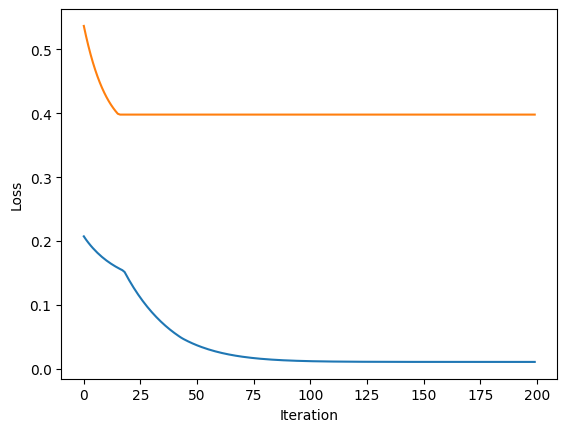

In [26]:
plt.plot(range(len(losses)), losses)
plt.plot(range(len(losses_original)), losses_original)
plt.ylabel('Loss')
plt.xlabel('Iteration')
plt.show()

# y_pred = single_neuron.forward(x_true)

In [ ]:
da2 = 2 * (y_pred - y_true) / y_true.size

In [ ]:
drelu = relu_derivative(single_neuron.output_layer._z_output)

In [ ]:
da1 = single_neuron.output_layer._input

In [ ]:
np.dot(da2, drelu.T, da1)

In [ ]:
np.dot(da2.T, da1)

In [ ]:
da = np.dot(np.dot(da2.T, relu_derivative(single_neuron.hidden_layer._z_output)), single_neuron.hidden_layer.weights.T)

In [1]:
import inspect